<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Week5_Random_Forest_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

AIM:To implement the Random Forest Algorithm and evaluate the model performance using appropriate metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/ML_Dataset/banking.csv"
df = pd.read_csv(path)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [5]:
df.shape

(41188, 21)

In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
df.isnull().sum()
df = df.dropna()

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [12]:
# Define Features and Target
X = df.drop("y", axis=1)
Y = df["y"]

In [17]:
X.head()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,44,210,1,999,0,1.4,93.444,-36.1,4.963,5228.1,...,False,False,False,False,False,True,False,False,True,False
1,53,138,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,...,False,True,False,False,False,False,False,False,True,False
2,28,339,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,...,False,False,False,False,False,True,False,False,False,True
3,39,185,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,...,False,False,False,False,False,False,False,False,True,False
4,55,137,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,...,False,False,False,False,False,False,False,False,False,True


In [18]:
Y.head()

,y
0,0
1,0
2,1
3,0
4,1


In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=0)

In [15]:
Y_pred = rf_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9094440398154892


In [19]:
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))


Confusion Matrix:
 [[10554   377]
 [  742   684]]


In [20]:
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     10931
           1       0.64      0.48      0.55      1426

    accuracy                           0.91     12357
   macro avg       0.79      0.72      0.75     12357
weighted avg       0.90      0.91      0.90     12357



In [21]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10931
           1       0.64      0.48      0.55      1426

    accuracy                           0.91     12357
   macro avg       0.79      0.72      0.75     12357
weighted avg       0.90      0.91      0.90     12357



In [22]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
1,duration,3.006430e-01
8,euribor3m,9.680317e-02
0,age,8.506083e-02
9,nr_employed,5.053921e-02
2,campaign,4.073236e-02
3,pdays,3.056960e-02
7,cons_conf_idx,2.809988e-02
52,poutcome_success,2.416343e-02
6,cons_price_idx,2.406434e-02
5,emp_var_rate,2.175089e-02


In [23]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<BarContainer object of 53 artists>

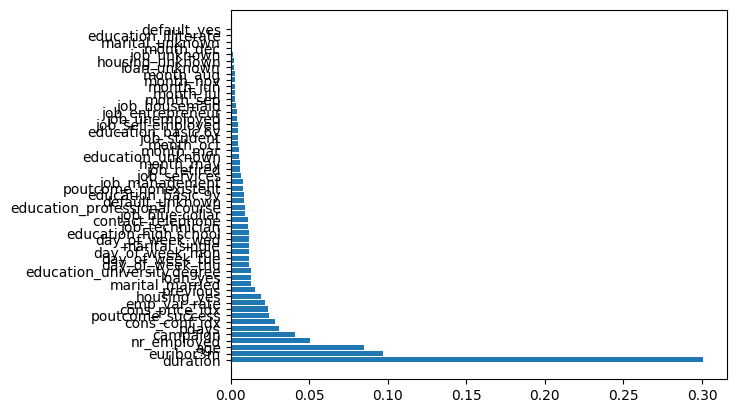

In [24]:
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])

Text(0.5, 0, 'Importance')

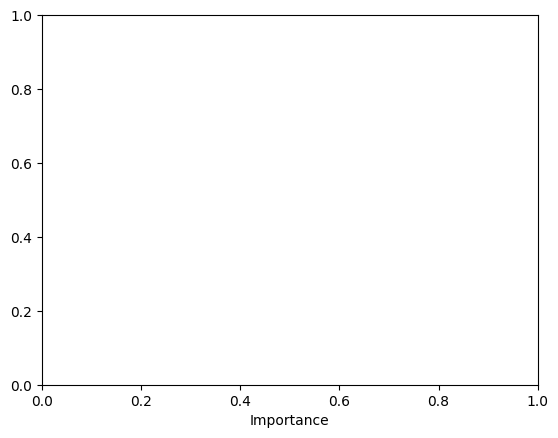

In [25]:
plt.xlabel("Importance")

Text(0.5, 1.0, 'Feature Importance in Random Forest')

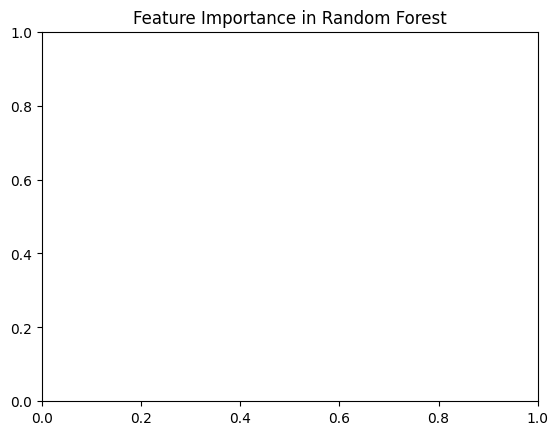

In [26]:
plt.title("Feature Importance in Random Forest")

In [28]:
estimators = [10, 50, 100, 200]
accuracies = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=0)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(Y_test, y_pred))

In [29]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

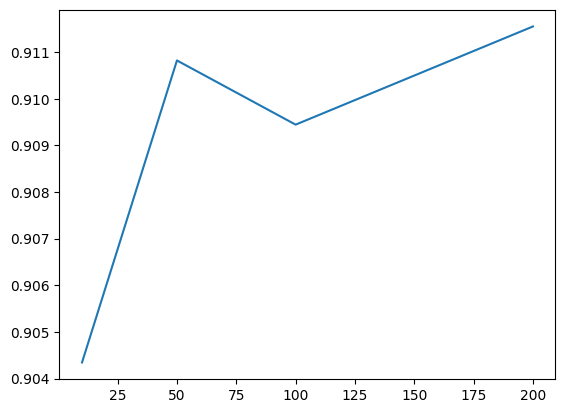

In [30]:
plt.plot(estimators, accuracies)

Text(0.5, 0, 'Number of Trees')

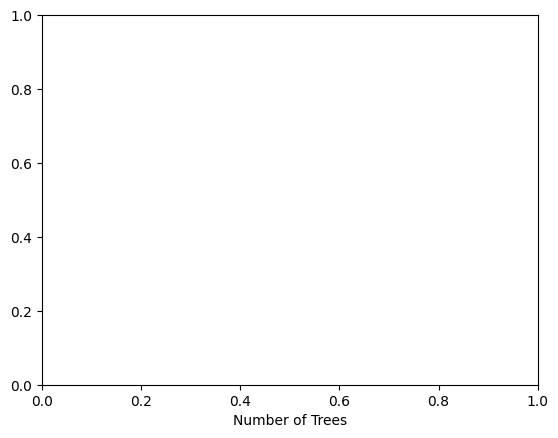

In [31]:
plt.xlabel("Number of Trees")

Text(0, 0.5, 'Accuracy')

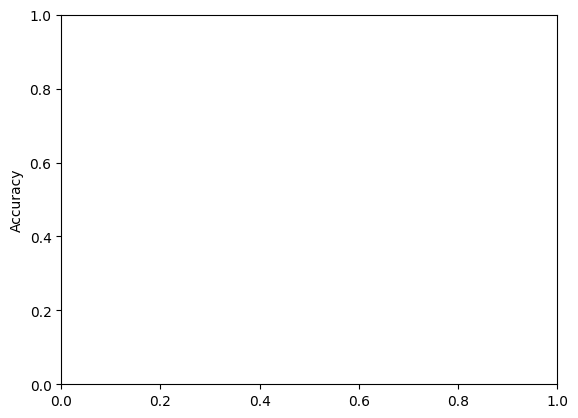

In [32]:
plt.ylabel("Accuracy")

Text(0.5, 1.0, 'Effect of n_estimators')

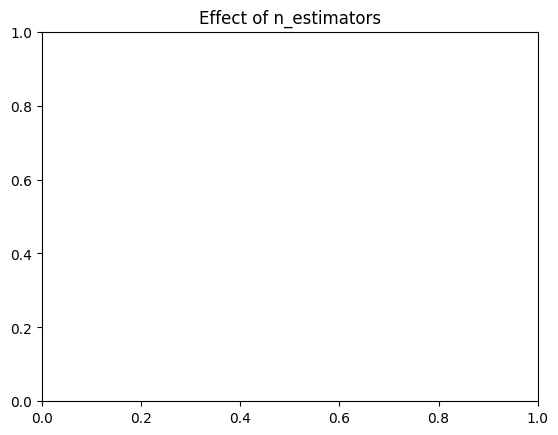

In [33]:
plt.title("Effect of n_estimators")